# OS Model 

To determine parameters (min, max, standard deviation, and mean) for all Fitzpatrick sets and temperature set. 

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

## Ftizpatrick parameters

Load in the fitz datasets from the Skin Tone Analysis

In [3]:
fitz_1=pd.read_csv("../Skin Tone Analysis/fitz_1.csv")
fitz_2=pd.read_csv("../Skin Tone Analysis/fitz_2.csv")
fitz_3=pd.read_csv("../Skin Tone Analysis/fitz_3.csv")
fitz_4=pd.read_csv("../Skin Tone Analysis/fitz_4.csv")
fitz_5=pd.read_csv("../Skin Tone Analysis/fitz_5.csv")
fitz_6=pd.read_csv("../Skin Tone Analysis/fitz_6.csv")

Filter outliers for `oxy_sat_comparison` for each fitz and create a distribution for output errors to input into skin tone component in final equation.

Create a range of bias values for a range OS values for each fitz value. Where the OS ranges will be based on the healhy/ diseased status:
- Healthy: 95-100 
- Placeholder: 92-94
- Hypoxia: >92

This will be the raw data that should be included in the microcontroller.

In [4]:
def group_by_saturation(df):
    """Group the DataFrame by so2_mean (true OS not measured by pulse ox) into defined bins.
    """
    # Group so2_mean into bins
    # Update to bins (95-100 is healthy, <92 is hypoxia, 92-94 is Slightly below normal) 2/18/2026
    bins = [0, 92, 95, 100]
    # Define labels for the bins
    labels = ['Hypoxia', 'Slightly below normal', 'Healthy']
    # Create a new column 'so2_group' based on the bins
    df['so2_group'] = pd.cut(df['so2_mean'], bins=bins, labels=labels)
    return df

In [5]:
fitz_1

,encounter_id,sample_number,saturation,so2_filled,saturation_mean,so2_mean,oxy_sat_comparison,fitzpatrick
0,023153e2349d0b1fd2677b51e963194f83fe919e52c12b...,2.0,"[96.0, 96.0, 96.0, 97.0, 96.0, 97.0, 96.0, 96....","[96.6, 96.4]",96.3,96.50,-0.20,1.0
1,023153e2349d0b1fd2677b51e963194f83fe919e52c12b...,3.0,"[97.0, 96.0, 97.0, 97.0, 96.0, 97.0, 97.0, 97....","[96.4, 96.2]",96.7,96.30,0.40,1.0
2,023153e2349d0b1fd2677b51e963194f83fe919e52c12b...,4.0,"[96.0, 96.0, 97.0, 97.0, 96.0, 97.0, 97.0, 97....","[96.6, 96.8]",96.6,96.70,-0.10,1.0
3,023153e2349d0b1fd2677b51e963194f83fe919e52c12b...,5.0,"[96.0, 96.0, 97.0, 97.0, 96.0, 97.0, 97.0, 96....","[96.5, 96.8]",96.5,96.65,-0.15,1.0
4,023153e2349d0b1fd2677b51e963194f83fe919e52c12b...,6.0,"[88.0, 88.0, 88.0, 89.0, 87.0, 87.0, 84.0, 86....","[87.4, 87.6]",86.6,87.50,-0.90,1.0
...,...,...,...,...,...,...,...,...
2093,f85b6055e849faa315493022ebeee01adbfa23faa99adc...,21.0,"[83.0, 81.0]",[83.6],82.0,83.60,-1.60,1.0
2094,f85b6055e849faa315493022ebeee01adbfa23faa99adc...,23.0,"[71.0, 68.0]",[70.8],69.5,70.80,-1.30,1.0
2095,f85b6055e849faa315493022ebeee01adbfa23faa99adc...,24.0,"[72.0, 68.0]",[70.8],70.0,70.80,-0.80,1.0
2096,f85b6055e849faa315493022ebeee01adbfa23faa99adc...,25.0,"[70.0, 67.0]",[69.6],68.5,69.60,-1.10,1.0


In [6]:
group_by_saturation(fitz_1)
group_by_saturation(fitz_2)
group_by_saturation(fitz_3)
group_by_saturation(fitz_4)
group_by_saturation(fitz_5)
group_by_saturation(fitz_6)

,encounter_id,sample_number,saturation,so2_filled,saturation_mean,so2_mean,oxy_sat_comparison,fitzpatrick,so2_group
0,02c37e54017643ceb7b0a9cdc05348c6737a1aa6434d0e...,2.0,"[97.9, 97.0, 98.0, 94.0]","[94.8, 94.6]",96.725,94.700000,2.025000,6.0,Slightly below normal
1,02c37e54017643ceb7b0a9cdc05348c6737a1aa6434d0e...,3.0,"[97.4, 96.0, 97.0, 98.0, 94.0]","[94.4, 94.1]",96.480,94.250000,2.230000,6.0,Slightly below normal
2,02c37e54017643ceb7b0a9cdc05348c6737a1aa6434d0e...,4.0,"[97.4, 96.0, 96.0, 98.0, 94.0]","[94.2, 93.8, 94.5]",96.280,94.166667,2.113333,6.0,Slightly below normal
3,02c37e54017643ceb7b0a9cdc05348c6737a1aa6434d0e...,5.0,"[97.0, 96.0, 94.0, 97.0, 94.0]","[94.0, 93.9]",95.600,93.950000,1.650000,6.0,Slightly below normal
4,02c37e54017643ceb7b0a9cdc05348c6737a1aa6434d0e...,6.0,"[86.0, 93.0, 89.0, 82.0]","[84.0, 83.5]",87.500,83.750000,3.750000,6.0,Hypoxia
...,...,...,...,...,...,...,...,...,...
3645,ff340351558c84be44dc642830770aeed2f91215f86f5f...,21.0,"[85.0, 84.0, 81.0, 84.0]","[79.2, 79.4]",83.500,79.300000,4.200000,6.0,Hypoxia
3646,ff340351558c84be44dc642830770aeed2f91215f86f5f...,22.0,"[82.0, 81.0, 80.0, 80.0]","[76.8, 76.4]",80.750,76.600000,4.150000,6.0,Hypoxia
3647,ff340351558c84be44dc642830770aeed2f91215f86f5f...,23.0,"[81.0, 80.0, 79.0]","[76.3, 76.4]",80.000,76.350000,3.650000,6.0,Hypoxia
3648,ff340351558c84be44dc642830770aeed2f91215f86f5f...,24.0,"[81.0, 77.0, 81.0, 79.0]","[75.7, 76.2]",79.500,75.950000,3.550000,6.0,Hypoxia


Exclude outliers from each oxy_sat_comparison values using IQR truncation. 

In [7]:
def truncate_by_group_iqr(df, so2_group, bias, k=1.5):
    """Truncate outliers in the DataFrame based on the IQR method for each group defined by so2_group.
    """
    def truncate(group):

    # Calculate the first and third quartiles and the IQR for the oxy_sat_comparison column
        q1 = group[bias].quantile(0.25)
        q3 = group[bias].quantile(0.75)
        iqr = q3 - q1
    # Define the lower and upper bounds for outliers
        lower = q1 - k * iqr
        upper = q3 + k * iqr
    # Return the group with outliers removed
        return group[(group[bias] >= lower) &
                     (group[bias] <= upper)]
    
    # Apply the truncate function to each group defined by so2_group and conc the results
    return (
        df.groupby(so2_group, group_keys=False)
          .apply(truncate)
          .reset_index(drop=True)
    )


Truncate by group for each fitz df (1-6)

In [8]:
fitz_1_trunx=truncate_by_group_iqr(fitz_1, 'so2_group', 'oxy_sat_comparison')
fitz_2_trunx=truncate_by_group_iqr(fitz_2, 'so2_group', 'oxy_sat_comparison')
fitz_3_trunx=truncate_by_group_iqr(fitz_3, 'so2_group', 'oxy_sat_comparison')
fitz_4_trunx=truncate_by_group_iqr(fitz_4, 'so2_group', 'oxy_sat_comparison')
fitz_5_trunx=truncate_by_group_iqr(fitz_5, 'so2_group', 'oxy_sat_comparison')
fitz_6_trunx=truncate_by_group_iqr(fitz_6, 'so2_group', 'oxy_sat_comparison')

In [9]:
fitz_1_trunx.to_csv("fitz_1_model.csv", index=False)
fitz_2_trunx.to_csv("fitz_2_model.csv", index=False)
fitz_3_trunx.to_csv("fitz_3_model.csv", index=False)
fitz_4_trunx.to_csv("fitz_4_model.csv", index=False)
fitz_5_trunx.to_csv("fitz_5_model.csv", index=False)
fitz_6_trunx.to_csv("fitz_6_model.csv", index=False)

Check: Ensure counts and means values are similar but with smaller range of mins and maxs between og df and trunx df.

In [10]:
fitz_1.groupby('so2_group')['oxy_sat_comparison'].describe()


,count,mean,std,min,25%,50%,75%,max
so2_group,,,,,,,,
Hypoxia,1442.0,0.457138,1.886115,-11.200000,-0.520238,0.5,1.550000,9.966667
Slightly below normal,331.0,1.045986,1.405399,-2.200000,-0.008333,0.9,1.914286,5.950000
Healthy,325.0,0.625420,1.144952,-2.271429,-0.200000,0.6,1.441667,3.400000


In [11]:
fitz_1_trunx.groupby('so2_group')['oxy_sat_comparison'].describe()

,count,mean,std,min,25%,50%,75%,max
so2_group,,,,,,,,
Hypoxia,1387.0,0.564727,1.516566,-3.600000,-0.400000,0.55,1.541667,4.600000
Slightly below normal,326.0,0.980553,1.310840,-2.200000,-0.041667,0.90,1.862500,4.666667
Healthy,325.0,0.625420,1.144952,-2.271429,-0.200000,0.60,1.441667,3.400000


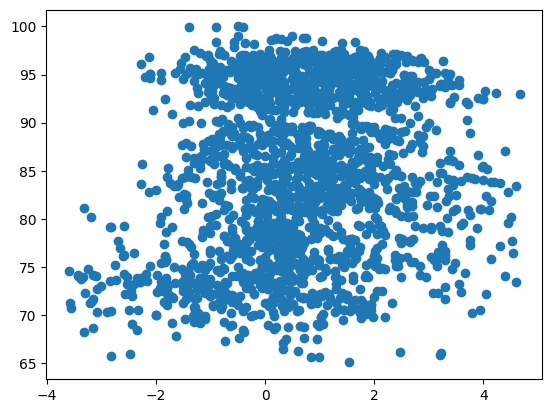

In [12]:
plt.scatter(fitz_1_trunx['oxy_sat_comparison'], (fitz_1_trunx['so2_mean']))

In [13]:
fitz_2_trunx.groupby('so2_group')['oxy_sat_comparison'].describe()

,count,mean,std,min,25%,50%,75%,max
so2_group,,,,,,,,
Hypoxia,1852.0,0.898793,1.635143,-3.316667,-0.133333,0.738889,1.943254,5.2
Slightly below normal,441.0,1.003676,1.404788,-2.150000,-0.100000,0.850000,2.100000,4.4
Healthy,460.0,0.567884,1.233233,-3.050000,-0.325794,0.350000,1.500000,3.6


In [14]:
fitz_3_trunx.groupby('so2_group')['oxy_sat_comparison'].describe()

,count,mean,std,min,25%,50%,75%,max
so2_group,,,,,,,,
Hypoxia,2145.0,1.308663,1.597991,-2.90,0.3000,1.200000,2.300000,5.6
Slightly below normal,517.0,1.185776,1.586948,-2.45,0.0000,0.950000,2.266667,5.7
Healthy,491.0,0.570182,1.092596,-2.30,-0.1875,0.478571,1.300000,3.4


In [15]:
fitz_4_trunx.groupby('so2_group')['oxy_sat_comparison'].describe()

,count,mean,std,min,25%,50%,75%,max
so2_group,,,,,,,,
Hypoxia,1869.0,1.224841,1.547669,-3.00,0.20000,1.178571,2.216667,5.50
Slightly below normal,467.0,0.797348,1.193721,-2.05,0.05625,0.700000,1.562500,3.80
Healthy,468.0,0.399618,0.928121,-2.20,-0.25000,0.350000,1.000000,2.65


In [16]:
fitz_5_trunx.groupby('so2_group')['oxy_sat_comparison'].describe()

,count,mean,std,min,25%,50%,75%,max
so2_group,,,,,,,,
Hypoxia,1105.0,2.164548,2.102538,-3.800000,6.500000e-01,2.050000,3.650000,8.00
Slightly below normal,272.0,1.374896,1.565829,-2.466667,2.500000e-01,1.258333,2.512500,5.05
Healthy,234.0,0.996104,1.347675,-2.200000,-1.065814e-14,0.833333,1.854167,4.50


In [17]:
fitz_6_trunx.groupby('so2_group')['oxy_sat_comparison'].describe()

,count,mean,std,min,25%,50%,75%,max
so2_group,,,,,,,,
Hypoxia,2489.0,2.522388,1.989897,-2.955556,1.155556,2.433333,3.85000,8.0
Slightly below normal,536.0,1.749996,1.257083,-1.750000,0.883333,1.726136,2.58125,4.9
Healthy,539.0,1.163272,1.004038,-1.700000,0.450000,1.200000,1.87500,3.7


Check distribution through scatterplot

Gather distribution value for temp ranges based on an input temp value or low perfusion (15-18 degrees C).
Temp ranges gathered is on for colder temperatures (18-20 degrees C) which could be seen as low perfusion.

Pulse ox eading IQR: 97.5 - 100
Culse pulse ox reading IQR: 87.1 - 92.7

## Temperature Parameters

Load in the excel sheet with data from the publication (https://doi.org/10.1016/j.ifacol.2015.10.166) from *Table 1. Blood oxygen saturation data for all subjects from the experiment*. Where NBP-75 is a pulse oximetry readings and PO is a customized measurement of oxygen saturation.

In [18]:
temp_data=pd.read_excel("OS_Model_Temp_Bias_02_2026_MA.xlsx")

In [19]:
temp_data

,NBP-75,PO
0,99,93.6
1,97,87.4
2,100,86.2
3,100,89.1
4,89,84.6
5,100,87.8
6,100,87.5
7,95,86.3
8,98,92.4
9,87,86.9


Create bias column to demonstrate the bias comparison value when measuring oxygen saturation with a pulse oximeter.

In [20]:
temp_data['temp_bias']=temp_data['NBP-75']-temp_data['PO']

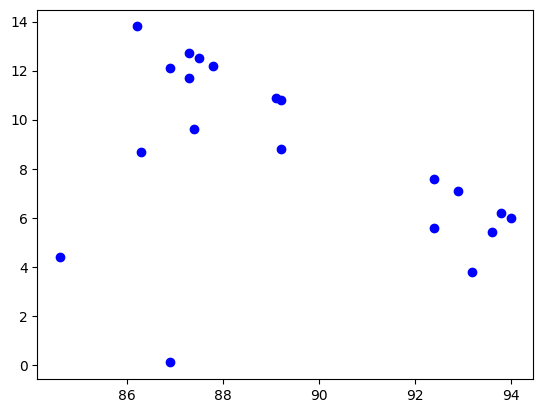

In [21]:
plt.scatter(temp_data['PO'], temp_data['temp_bias'], color='blue', label='Data Points')

In [22]:
temp_data

,NBP-75,PO,temp_bias
0,99,93.6,5.4
1,97,87.4,9.6
2,100,86.2,13.8
3,100,89.1,10.9
4,89,84.6,4.4
5,100,87.8,12.2
6,100,87.5,12.5
7,95,86.3,8.7
8,98,92.4,5.6
9,87,86.9,0.1


Here it can be seen that MAJORITY of PO values are read as >97 with the NBP-75 pulse oximeter which is largely skewed. Here we will assume that whatever the true OS value is that is almost always going to be largely skewed. Create a range based on bias values to include in OS model for the temperature bias.

In [23]:
print("Min: ", temp_data['temp_bias'].min(), "\nMax: ", temp_data['temp_bias'].max(), "\nStd: ", temp_data['temp_bias'].std(), "\nMean: ", temp_data['temp_bias'].mean())

Min:  0.09999999999999432 
Max:  13.799999999999997 
Std:  3.6476380245159663 
Mean:  8.499999999999998
